In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df_3 = pd.read_csv(r"C:\Users\Ashutosh Bhatt\Churn_Model\Scaled Churn Dataset.csv")
df_3.head()

,Unnamed: 0,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceToSalaryRatio,IsZeroBalance,ProductPerYear,AgeGroup_Encoded,Gender_Encoded,Geography_Encoded,Geo_Gender_Encoded
0,0,-0.326878,0.342615,-1.041760,-1.225848,-0.924827,1,1,0.021886,1,-0.037882,1,-0.098704,0.0,0,0,0
1,1,-0.440804,0.240011,-1.387538,0.117350,-0.924827,0,1,0.216534,0,-0.030439,0,0.396531,0.0,0,2,4
2,2,-1.538636,0.342615,1.032908,1.333053,2.583620,1,0,0.240687,1,-0.023876,0,-0.098704,0.0,0,0,0
3,3,0.501675,0.034803,-1.387538,-1.225848,0.829397,0,0,-0.108918,0,-0.037882,1,1.882234,0.0,0,0,0
4,4,2.065569,0.445219,-1.041760,0.785728,-0.924827,1,1,-0.365276,0,-0.022020,0,-0.098704,0.0,0,2,4


**Feature Selection**

In [40]:
# Correaltion Coefficient
correlation = df_3.corr()
print(correlation['Exited'].sort_values(ascending=False))


Exited                  1.000000
Age                     0.312436
Balance                 0.118533
Geography_Encoded       0.035943
BalanceToSalaryRatio    0.025963
EstimatedSalary         0.012097
AgeGroup_Encoded        0.006626
Geo_Gender_Encoded      0.003728
HasCrCard              -0.007138
ProductPerYear         -0.010056
Tenure                 -0.014001
Unnamed: 0             -0.016571
CreditScore            -0.026455
NumOfProducts          -0.059196
Gender_Encoded         -0.106512
IsZeroBalance          -0.122357
IsActiveMember         -0.156128
Name: Exited, dtype: float64


In [41]:
target_corr = df_3.corr()['Exited'].abs().sort_values(ascending=False)
weak_features = target_corr.drop('Exited')
weak_features = target_corr[target_corr < 0.05].index.tolist()
print("Weak features to consider dropping:", weak_features)

Weak features to consider dropping: ['Geography_Encoded', 'CreditScore', 'BalanceToSalaryRatio', 'Unnamed: 0', 'Tenure', 'EstimatedSalary', 'ProductPerYear', 'HasCrCard', 'AgeGroup_Encoded', 'Geo_Gender_Encoded']


In [42]:
df_3.head()

,Unnamed: 0,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceToSalaryRatio,IsZeroBalance,ProductPerYear,AgeGroup_Encoded,Gender_Encoded,Geography_Encoded,Geo_Gender_Encoded
0,0,-0.326878,0.342615,-1.041760,-1.225848,-0.924827,1,1,0.021886,1,-0.037882,1,-0.098704,0.0,0,0,0
1,1,-0.440804,0.240011,-1.387538,0.117350,-0.924827,0,1,0.216534,0,-0.030439,0,0.396531,0.0,0,2,4
2,2,-1.538636,0.342615,1.032908,1.333053,2.583620,1,0,0.240687,1,-0.023876,0,-0.098704,0.0,0,0,0
3,3,0.501675,0.034803,-1.387538,-1.225848,0.829397,0,0,-0.108918,0,-0.037882,1,1.882234,0.0,0,0,0
4,4,2.065569,0.445219,-1.041760,0.785728,-0.924827,1,1,-0.365276,0,-0.022020,0,-0.098704,0.0,0,2,4


In [43]:
# dropping the weak correaltion columns
df_3 = df_3.drop(columns = weak_features)

In [44]:
df_3

,Age,Balance,NumOfProducts,IsActiveMember,Exited,IsZeroBalance,Gender_Encoded
0,0.342615,-1.225848,-0.924827,1,1,1,0
1,0.240011,0.117350,-0.924827,1,0,0,0
2,0.342615,1.333053,2.583620,0,1,0,0
3,0.034803,-1.225848,0.829397,0,0,1,0
4,0.445219,0.785728,-0.924827,1,0,0,0
...,...,...,...,...,...,...,...
9995,0.034803,-1.225848,0.829397,0,0,1,1
9996,-0.375612,-0.306379,-0.924827,1,0,0,1
9997,-0.273008,-1.225848,-0.924827,1,1,1,0
9998,0.342615,-0.022608,0.829397,0,1,0,1


**Training,Testing Dataset**

In [45]:
from sklearn.model_selection import train_test_split

X = df_3.drop('Exited', axis=1) # all features exculding Exited
y= df_3['Exited'] # predicted feature

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size =0.2,random_state=42)

In [46]:
from sklearn.linear_model import (LogisticRegression)
from sklearn.metrics import (precision_score, recall_score,f1_score,confusion_matrix , accuracy_score,classification_report)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# Evaluation
print('Accuracy:', accuracy_score(y_test,y_pred))
print('Confusion Matrix:', confusion_matrix(y_test ,y_pred))
print('Classification Report:' ,classification_report(y_test,y_pred))
print('Precision Score :' ,precision_score(y_test,y_pred))
print('Recall Score:' ,recall_score(y_test,y_pred))
print('F1 Score:' ,f1_score(y_test,y_pred))

Accuracy: 0.824
Confusion Matrix: [[1562   45]
 [ 307   86]]
Classification Report:               precision    recall  f1-score   support

           0       0.84      0.97      0.90      1607
           1       0.66      0.22      0.33       393

    accuracy                           0.82      2000
   macro avg       0.75      0.60      0.61      2000
weighted avg       0.80      0.82      0.79      2000

Precision Score : 0.6564885496183206
Recall Score: 0.21882951653944022
F1 Score: 0.3282442748091603


AUC Score: 0.7733199694086463


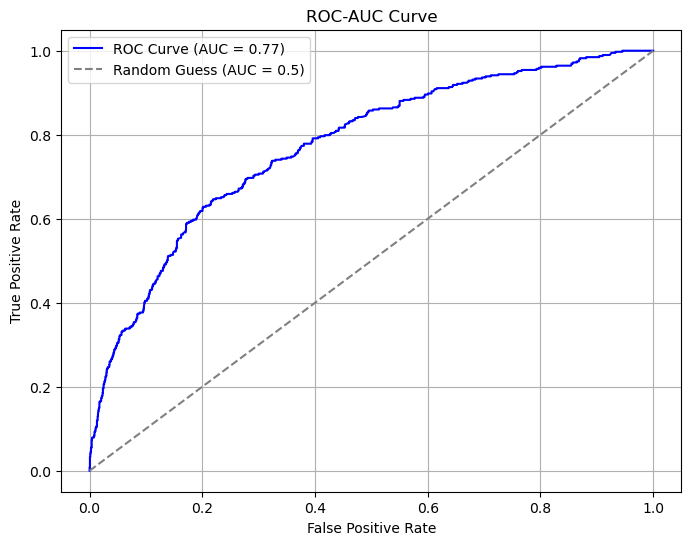

In [47]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
y_pred_proba = model.predict_proba(X_test)[:, 1]  

auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC Score:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC AUC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# data is imbalanced .. for balancing the data we adding weights
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


The dataset is imbalance using SMOTE used only train data ,not using test data. It is used to fixed target class imbalance in dataset prior to model training

In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

model.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


This code evaluates how well the classifier performs when we adjust the descison threshold to identify positive churn.

In [50]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_new = (y_pred_proba >= 0.4).astype(int)  

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.93      0.55      0.69      1607
           1       0.31      0.83      0.45       393

    accuracy                           0.61      2000
   macro avg       0.62      0.69      0.57      2000
weighted avg       0.81      0.61      0.65      2000



for better performance using random forest not logistic regression

In [51]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred = model.predict(X_test)

# Evaluation
print('Accuracy:', accuracy_score(y_test,y_pred))
print('Confusion Matrix:', confusion_matrix(y_test ,y_pred))
print('Classification Report:' ,classification_report(y_test,y_pred))
print('Precision Score :' ,precision_score(y_test,y_pred))
print('Recall Score:' ,recall_score(y_test,y_pred))
print('F1 Score:' ,f1_score(y_test,y_pred))

Accuracy: 0.8325
Confusion Matrix: [[1457  150]
 [ 185  208]]
Classification Report:               precision    recall  f1-score   support

           0       0.89      0.91      0.90      1607
           1       0.58      0.53      0.55       393

    accuracy                           0.83      2000
   macro avg       0.73      0.72      0.73      2000
weighted avg       0.83      0.83      0.83      2000

Precision Score : 0.5810055865921788
Recall Score: 0.5292620865139949
F1 Score: 0.5539280958721704


AUC Score: 0.7891389610656938


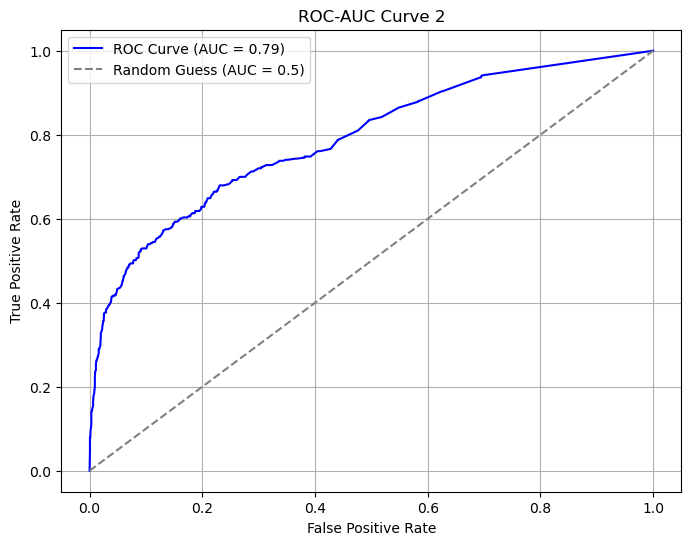

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
y_pred_proba = model.predict_proba(X_test)[:, 1]  

auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC Score:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC AUC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve 2')
plt.legend()
plt.grid(True)
plt.show()

**Hyperparameter Tunning**

In [55]:
# Grid Search CV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross validation
    scoring='f1',            #  metric optimize  (f1 -imbalanced data)
    n_jobs=-1,                # Use CPU cores  (fast)
    verbose=2                 # Show progress 
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best F1 Score: 0.5947768981219774
              precision    recall  f1-score   support

           0       0.91      0.84      0.88      1607
           1       0.51      0.67      0.58       393

    accuracy                           0.81      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.81      0.82      2000



In [56]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,               #  random combinations for trying
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=2
)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
Best F1 Score: 0.5904424724696338
              precision    recall  f1-score   support

           0       0.91      0.84      0.88      1607
           1       0.51      0.67      0.58       393

    accuracy                           0.81      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.81      0.82      2000



Seeing the feature importance . This chart will show which feature is important during churning

<Axes: >

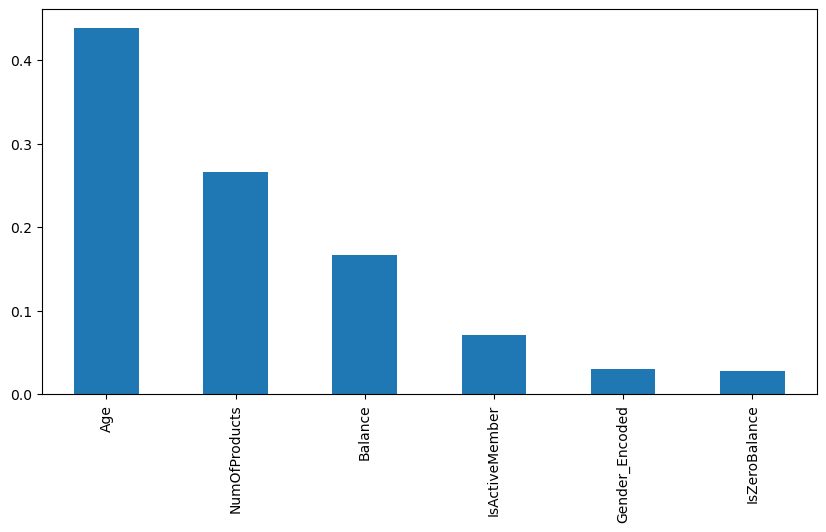

In [58]:
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))

In [63]:
import joblib
joblib.dump(best_model, 'churn_prediction_model.pkl')


['churn_prediction_model.pkl']